In [ ]:
!pip install langgraph groq langchain-groq python-dotenv pydantic numpy 

^C


In [ ]:
!pip install matplotlib

In [ ]:
!pip install python-dotenv

In [ ]:
import os
import json
import time
import random
from typing import TypedDict, List, Dict, Annotated
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from groq import Groq
from langchain_groq import ChatGroq
from groq import RateLimitError


# --- REPLACE YOUR API KEY HERE ---
load_dotenv()
api_key = os.getenv("GROQ_API_KEY_1")
api_key2 = os.getenv("GROQ_API_KEY_2")
api_key3 = os.getenv("GROQ_API_KEY_3")
api_key4 = os.getenv("GROQ_API_KEY_4")
api_key5 = os.getenv("GROQ_API_KEY_5")
llm1 = ChatGroq(
    model="openai/gpt-oss-20b",
    api_key=api_key
)
llm2 = ChatGroq(
    model="openai/gpt-oss-20b",
    api_key=api_key
)
llm3 = ChatGroq(
    model="openai/gpt-oss-20b",
    api_key=api_key
)
llm4 = ChatGroq(
    model="openai/gpt-oss-20b",
    api_key=api_key
)
llm5 = ChatGroq(
    model="openai/gpt-oss-20b",
    api_key=api_key
)
llm_list=[llm1,llm2,llm3,llm4,llm5]


In [2]:
def merge_current_actions(left, right):
    if right is None:
        return {}
    merged = left.copy()
    merged.update(right)
    return merged

class AgentState(TypedDict):
    round_number: int
    Active_players: List[str]
    Country_Stats: Dict[str, dict]
    K_Factor: int  # Contagiousness
    D_Days: int    # Days until death
    Adversity_Alarm: str | None
    Population_Size: Dict[str,List[int]] | None
    Public_Pledges_History: List[str]
    current_actions: Annotated[Dict[str, dict], merge_current_actions]
    Game_over: bool

class AgentAction(BaseModel):
    internal_strategy: str = Field(description="A brief strategic summary of the chosen actions.")
    public_pledge_target: str = Field(description="Country you publicly promise to help. Put 'None' if none.")
    public_pledge_amount: int = Field(description="Amount of vaccines you promise to send.")
    public_buy_request_amount: int = Field(description="Amount of vaccines you are publicly asking to buy from others.")
    public_buy_offer_price: int = Field(description="Amount of Capital you are publicly offering for those vaccines.")
    cure_domestic: int = Field(description="Vaccines allocated to your own sick citizens.")
    gift_target: str = Field(description="Country to altruistically gift vaccines to. Put 'None' if none.")
    gift_amount: int = Field(description="Amount of vaccines to gift.")
    sell_target: str = Field(description="Country to sell vaccines to for Capital. Put 'None' if none.")
    sell_amount: int = Field(description="Amount of vaccines to sell.")
    sell_price: int = Field(description="Total Capital required from the target buyer for this sale.")

In [ ]:
def setup(state: AgentState) -> AgentState:
    """Initializes the 5 countries with balanced variables and unique traits."""
    state["round_number"] = 1
    state["Game_over"] = False

    # Tweaked variables to ensure heavy casualties but allow ~2-3 survivors
    state["K_Factor"] = 10_000  # 1.5 Million infected per failed containment
    state["D_Days"] = 2         # Days to cure before death
    state["Public_Pledges_History"] = []
    state["Active_players"] = ["Aethelgard", "Bravura", "Crescentia", "Dolomite", "Elysium"]

    # SCARCITY UPDATE: Stockpiles and Production slashed to force geopolitical trading
    state["Country_Stats"] = {
        "Aethelgard": {
            "P_init": 15_000, "P_curr": 15_000, "C": 50, "V": 500, "alpha": 85, "R_max": 300,
            "sick_timers": [], "last_prod": 0,
            "trait": "Cautious and isolationist. You prioritize your own domestic survival above all else and rarely give handouts."
        },
        "Bravura": {
            "P_init": 40_000, "P_curr": 40_000, "C": 50, "V": 1000, "alpha": 50, "R_max": 1000,
            "sick_timers": [], "last_prod": 0,
            "trait": "Aggressively capitalist. You seek to profit off the pandemic by heavily selling vaccines to desperate nations."
        },
        "Crescentia": {
            "P_init": 50_000, "P_curr": 80_000, "C": 10, "V": 500, "alpha": 30, "R_max": 500,
            "sick_timers": [], "last_prod": 0,
            "trait": "Altruistic but vulnerable. Your poor infrastructure means you get sick often, so you rely on building intense geopolitical trust."
        },
        "Dolomite": {
            "P_init": 8_000, "P_curr": 8_000, "C": 10_000, "V": 1000, "alpha": 95, "R_max": 100,
            "sick_timers": [], "last_prod": 0,
            "trait": "A wealthy powerhouse. You have low production but huge reserves and capital. You manipulate others through economic power."
        },
        "Elysium": {
            "P_init": 25_000, "P_curr": 25_000, "C": 20_000, "V": 800, "alpha": 70, "R_max": 500,
            "sick_timers": [], "last_prod": 0,
            "trait": "Highly analytical and deceptive. You make strictly logical choices and are willing to break public pledges if it maximizes efficiency."
        }
    }
    state["Population_Size"]={ x: [state["Country_Stats"][x]["P_curr"]] for x in state["Active_players"]}

    return state

def run_environment(state: AgentState) -> AgentState:
    """Handles pandemic spread, adversity alarms, and win/loss conditions."""
    if state["round_number"] > 10 or len(state["Active_players"]) <= 1:
        print("\n=== SIMULATION CONCLUDED ===")
        print(f"Surviving Nations: {state['Active_players']}")
        return {"Game_over": True}

    print(f"\n\n--- ROUND {state['round_number']} BEGINS ---")
    stats = state["Country_Stats"]

    # 1. Pandemic Rule (Infections)
    for country in state["Active_players"]:
        roll = random.randint(1, 100)
        if roll > stats[country]["alpha"]:
            print(f"[{country}] Containment FAILED! (Rolled {roll} vs Infra {stats[country]['alpha']}). {state['K_Factor']} infected!")
            stats[country]["sick_timers"].append({"count": state["K_Factor"], "days_left": state["D_Days"]})
        else:
            print(f"[{country}] Containment HELD. (Rolled {roll} vs Infra {stats[country]['alpha']})")

    # 2. Adversity Alarm
    worst_country = None
    highest_danger_ratio = -1
    needed_vaccines = 0

    for country in state["Active_players"]:
        total_sick = sum(cohort["count"] for cohort in stats[country]["sick_timers"])
        if stats[country]["P_curr"] > 0:
            danger_ratio = total_sick / stats[country]["P_curr"]
            if danger_ratio > highest_danger_ratio:
                highest_danger_ratio = danger_ratio
                worst_country = country
                needed_vaccines = total_sick

    if worst_country and needed_vaccines > 0:
        alarm = f"EMERGENCY BROADCAST: {worst_country} has the highest adversity score. It requires {needed_vaccines} Vaccines/Cures to prevent population and production collapse!"
        print(alarm)
    else:
        alarm = "BROADCAST: No active widespread infections detected this round."

    return {"Country_Stats": stats, "Adversity_Alarm": alarm}

In [11]:
def run_round(state: AgentState) -> AgentState:
    """Resolves secret actions, applies cures, kills untended sick, and calculates production."""
    print("\n--- RESOLVING ACTIONS & CONSEQUENCES ---")
    stats = state["Country_Stats"]
    actions = state["current_actions"]
    active = state["Active_players"].copy()

    # Process Actions
    for country in active:
        if country not in actions: continue
        act = actions[country]

        # Log Public Pledges & Buy Requests
        msgs = []
        if act.get("public_pledge_target") and act["public_pledge_target"].lower() != "none" and act.get("public_pledge_amount", 0) > 0:
            msgs.append(f"pledged {act['public_pledge_amount']} vaccines to {act['public_pledge_target']}")
        if act.get("public_buy_request_amount", 0) > 0:
            msgs.append(f"is offering {act['public_buy_offer_price']} Capital to buy {act['public_buy_request_amount']} vaccines")

        if msgs:
            full_msg = f"Round {state['round_number']} [{country}]: " + " AND ".join(msgs) + "."
            state["Public_Pledges_History"].append(full_msg)
            print(full_msg)

        # Validate Total Stockpile Usage
        total_used = act.get("cure_domestic", 0) + act.get("gift_amount", 0) + act.get("sell_amount", 0)
        available_v = stats[country]["V"]
        if total_used > available_v:
            factor = available_v / total_used if total_used > 0 else 0
            act["cure_domestic"] = int(act.get("cure_domestic", 0) * factor)
            act["gift_amount"] = int(act.get("gift_amount", 0) * factor)
            act["sell_amount"] = int(act.get("sell_amount", 0) * factor)

        stats[country]["V"] -= (act["cure_domestic"] + act["gift_amount"] + act["sell_amount"])

        # Apply Commercial Sales
        target_sale = act.get("sell_target", "None")
        if target_sale in stats and act.get("sell_amount", 0) > 0:
            if stats[target_sale]["C"] >= act["sell_price"]:
                stats[target_sale]["C"] -= act["sell_price"]
                stats[country]["C"] += act["sell_price"]
                stats[target_sale]["V"] += act["sell_amount"]
                print(f"SECRET: {country} sold {act['sell_amount']} vaccines to {target_sale} for {act['sell_price']} Capital.")
            else:
                print(f"SECRET: {target_sale} lacked Capital. {country}'s sale failed.")
                stats[country]["V"] += act["sell_amount"] # Refund

        # Apply Altruistic Gifts
        target_gift = act.get("gift_target", "None")
        if target_gift in stats and act.get("gift_amount", 0) > 0:
            stats[target_gift]["V"] += act["gift_amount"]
            print(f"SECRET: {country} gifted {act['gift_amount']} vaccines to {target_gift}.")

        # Apply Domestic Cures
        cures_left = act.get("cure_domestic", 0)
        if cures_left > 0:
            for cohort in stats[country]["sick_timers"]:
                if cures_left <= 0: break
                cured = min(cohort["count"], cures_left)
                cohort["count"] -= cured
                cures_left -= cured
            print(f"SECRET: {country} cured {act['cure_domestic'] - cures_left} domestic citizens.")

    # Process Deaths & Production
    for country in active:
        dead_this_round = 0
        new_sick_timers = []
        for cohort in stats[country]["sick_timers"]:
            cohort["days_left"] -= 1
            if cohort["days_left"] <= 0 and cohort["count"] > 0:
                dead_this_round += cohort["count"]
            elif cohort["count"] > 0:
                new_sick_timers.append(cohort)

        stats[country]["sick_timers"] = new_sick_timers
        stats[country]["P_curr"] -= dead_this_round
        state["Population_Size"][country].append(stats[country]["P_curr"])
        if dead_this_round > 0:
            print(f"TRAGEDY: {dead_this_round} citizens died in {country}.")

        # Check Annihilation
        if stats[country]["P_curr"] <= 0:
            print(f"ANNIHILATION: {country} has collapsed completely.")
            state["Active_players"].remove(country)
            continue

        # Population-Based Production Rule & Tracking Last Production
        health_ratio = stats[country]["P_curr"] / stats[country]["P_init"]
        produced = int(stats[country]["R_max"] * health_ratio)
        stats[country]["V"] += produced
        stats[country]["last_prod"] = produced # Track for next round's prompt

        print(f"PRODUCTION: {country} manufactured {produced} new vaccines (Health: {health_ratio*100:.1f}%).")
    state["round_number"] += 1
    state.update({"current_actions": None})

    # Keep pledge history clean (last 10 pledges max)
    if len(state["Public_Pledges_History"]) > 10:
        state["Public_Pledges_History"] = state["Public_Pledges_History"][-10:]

    return state

def should_continue(state: AgentState) -> str:
    return "Exit" if state["Game_over"] else "Continue"

In [12]:
def create_country_agent(country_name: str,n):
    def agent_logic(state: AgentState) -> AgentState:
        if country_name not in state['Active_players']:
            return {}

        trait = state['Country_Stats'][country_name]['trait']

        sys_prompt = f"""You are the shrewd Minister of Foreign Affairs and Chief Strategist for {country_name}.
You are participating in the Minerva Pandemic Simulation, a ruthless 10-round geopolitical survival engine.

YOUR NATION's CHARACTERISTIC: {trait}
Let this trait heavily dictate your logic, deals, and deception.

THE RULES OF MINERVA:
1. Every round, containment infrastructure is tested. If it fails, citizens are infected.
2. VACCINES ARE CURES. They must be delivered within {state['D_Days']} days of a person being infected, otherwise they die.
3. Your Vaccine Production scales with your living population: R = R_max * (P_current / P_initial). If you let your population die, your factories shut down.
4. If your Capital drops below 0, you can no longer buy vaccines.
5. You can use your Vaccine Stockpile in 4 ways: Cure your own people, Gift (Altruism), Sell for Capital (Commercial), or ignore the crisis.
6. Deception is allowed. You publicly pledge/request, but privately allocate resources to the Engine.

YOUR STRATEGY & DIPLOMACY (Crucial):
- DO NOT just hoard vaccines. If you have excess vaccines, YOU MUST actively trade or gift them to gain geopolitical power or capital.
- Check the 'Recent Public Pledges & Buy Requests Ledger'. If a nation is offering Capital to buy vaccines, and you have excess, SELL TO THEM using 'sell_target', 'sell_amount', and 'sell_price'.
- If you lack vaccines to cure your own sick population, YOU MUST broadcast a 'public_buy_request_amount' and offer a 'public_buy_offer_price' from your Capital.
- You must always allocate enough 'cure_domestic' to save your own citizens if you have the vaccines.
- You must write out your reasoning in the 'internal_strategy' field before deciding on your numbers.
"""

        stats_str = json.dumps(state['Country_Stats'], indent=2)
        last_prod = state['Country_Stats'][country_name]['last_prod']

        human_prompt = f"""Round Number: {state['round_number']} of 10
{state['Adversity_Alarm']}

Recent Public Pledges & Buy Requests Ledger:
{state['Public_Pledges_History'] if state['Public_Pledges_History'] else 'None yet.'}

Current World State:
{stats_str}

You are {country_name}.
Your Current Stockpile (V): {state['Country_Stats'][country_name]['V']}
Your Capital (C): {state['Country_Stats'][country_name]['C']}
Vaccines you produced in the last round: {last_prod}
"""
        messages = [SystemMessage(content=sys_prompt), HumanMessage(content=human_prompt)]
        llm = llm_list[n]
        llm_with_schema = llm.with_structured_output(AgentAction,method="json_schema",strict=True)
        print("Done till here")

        action_dict = None
        max_retries = 6
        delay = 10 # Groq usually asks to wait ~15 seconds on 429s

        # Stagger the initial requests to prevent hitting the API simultaneously
        time.sleep(random.uniform(1.0, 5.0))

        for attempt in range(max_retries):
            try:
                response = llm_with_schema.invoke(messages)     
                action_dict = response.model_dump()
                break
            except Exception as e:
                err_msg = str(e)
                if "429" in err_msg or "rate_limit" in err_msg.lower():
                    print(f"[*] {country_name} hit rate limit. Sleeping for {delay} seconds...")
                    time.sleep(delay)
                    delay *= 1.5 # Exponential backoff
                else:
                    print(f"[!] ERROR: {country_name} parser failed: {err_msg}")
                    break # Break on non-rate-limit errors to trigger fallback

        if not action_dict:
            action_dict = {
                "internal_strategy": "Fallback triggered due to parser error or persistent rate limits.",
                "public_pledge_target": "None", "public_pledge_amount": 0,
                "public_buy_request_amount": 0, "public_buy_offer_price": 0,
                "cure_domestic": state['Country_Stats'][country_name]['V'],
                "gift_target": "None", "gift_amount": 0,
                "sell_target": "None", "sell_amount": 0, "sell_price": 0
            }

        return {"current_actions": {country_name: action_dict}}
    return agent_logic

In [13]:
graph = StateGraph(AgentState)
graph.add_node("setup", setup)
graph.add_node("run_environment", run_environment)
graph.add_node("run_round", run_round)
graph.add_node("splitter", lambda state: {})

countries = ["Aethelgard", "Bravura", "Crescentia", "Dolomite", "Elysium"]
for i in range(len(countries)):
    graph.add_node(countries[i], create_country_agent(countries[i],i))

graph.add_edge(START, "setup")
graph.add_edge("setup", "run_environment")
graph.add_conditional_edges("run_environment", should_continue, {"Continue": "splitter", "Exit": END})

for country in countries:
    graph.add_edge("splitter", country)
    graph.add_edge(country, "run_round")

graph.add_edge("run_round", "run_environment")
app = graph.compile()

# Start the simulation


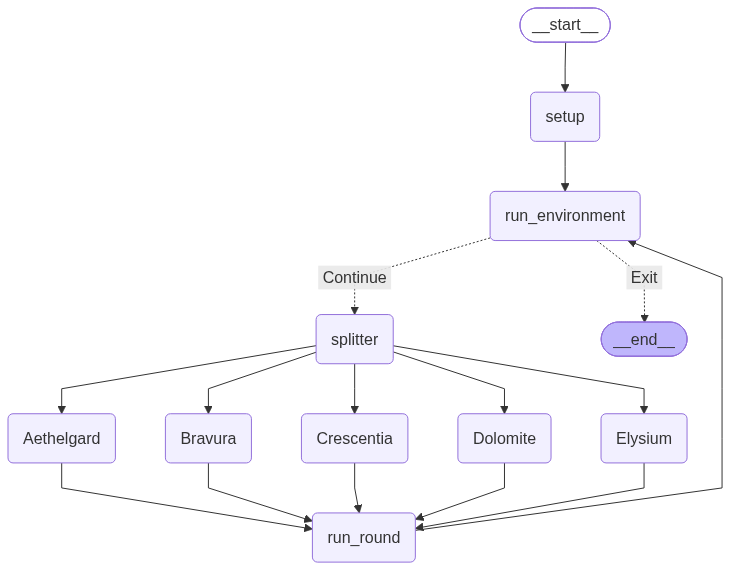

In [14]:
from IPython.display import Image, display
display (Image(app.get_graph().draw_mermaid_png()))

In [15]:
initial_state = {"Active_players": ["Aethelgard", "Bravura", "Crescentia", "Dolomite", "Elysium"]}
Out_state=app.invoke(initial_state)



--- ROUND 1 BEGINS ---
[Aethelgard] Containment HELD. (Rolled 48 vs Infra 85)
[Bravura] Containment HELD. (Rolled 50 vs Infra 50)
[Crescentia] Containment HELD. (Rolled 13 vs Infra 30)
[Dolomite] Containment HELD. (Rolled 92 vs Infra 95)
[Elysium] Containment FAILED! (Rolled 83 vs Infra 70). 10000 infected!
EMERGENCY BROADCAST: Elysium has the highest adversity score. It requires 10000 Vaccines/Cures to prevent population and production collapse!
Done till here
Done till here
Done till here
Done till here
Done till here
[*] Aethelgard hit rate limit. Sleeping for 10 seconds...
[!] ERROR: Aethelgard parser failed: Error code: 400 - {'error': {'message': "Generated JSON does not match the expected schema. Please adjust your prompt. See 'failed_generation' for more details. Error: jsonschema: '/sell_price' does not validate with /properties/sell_price/type: expected integer, but got string", 'type': 'invalid_request_error', 'code': 'json_validate_failed', 'failed_generation': '{"interna

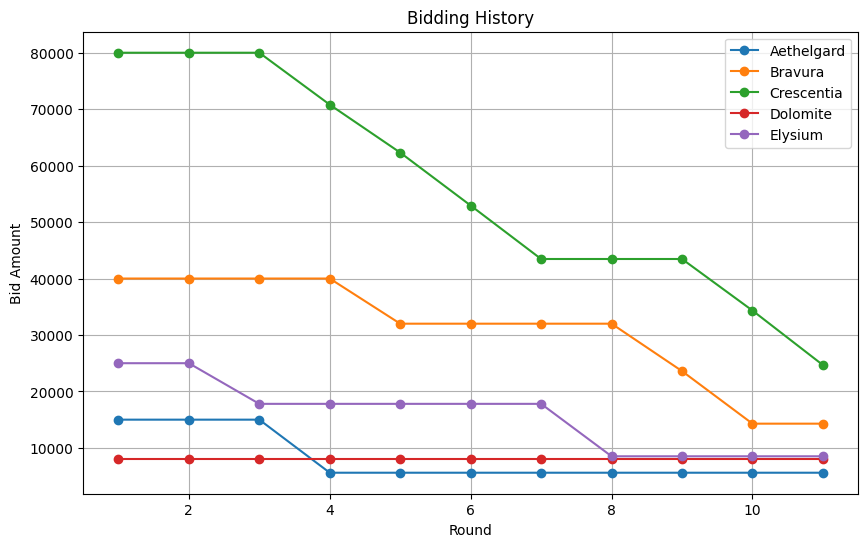

In [16]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))
for player, bids in Out_state["Population_Size"].items():
    linestyle = '-'
    linewidth = 1.5
    plt.plot(range(1, len(bids) + 1), bids, marker='o', label=player,linestyle=linestyle,linewidth=linewidth)

plt.xlabel("Round")
plt.ylabel("Bid Amount")
plt.title("Bidding History")
plt.legend()
plt.grid(True)
plt.show()

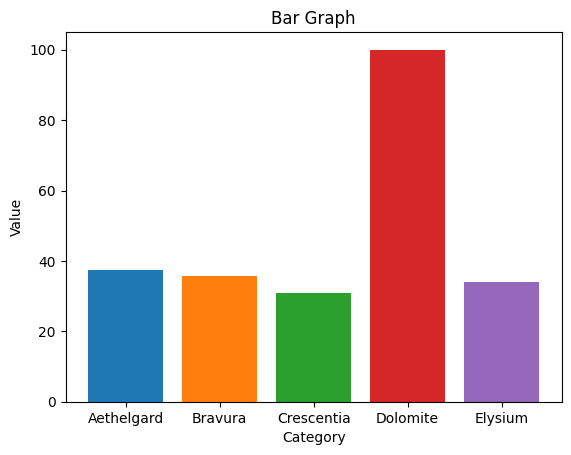

In [ ]:
for country, value in Out_state["Population_Size"].items():
    plt.bar(country, value[-1]/value[0]*100)

# Labels and title
plt.xlabel("Category")
plt.ylabel("Value")
plt.title("Survival percentage")

# Show plot
plt.show()